# Data Loading

In [106]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Data Overview

In [4]:
df = pd.read_csv('us_acc.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                55974 non-null   float64
 8   End_Lng                55974 non-null   float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            99999 non-null   str    
 11  Street                 99872 non-null   str    
 12  City                   99998 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-null  str    


In [6]:
df.head(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7696031,Source1,2,2017-08-15 17:44:25,2017-08-15 23:44:25,35.391090,-97.427620,35.390539,-97.420487,0.404,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-4418683,Source1,2,2022-12-05 17:00:04.000000000,2022-12-05 18:19:35.000000000,35.952093,-86.812483,35.965936,-86.807674,0.994,...,False,False,False,False,False,False,Night,Day,Day,Day
2,A-1049861,Source2,2,2021-05-11 07:10:07,2021-05-11 07:39:46,37.495079,-77.478523,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-5809156,Source1,2,2021-08-20 11:27:30,2021-08-20 13:33:44,33.987420,-118.188210,33.987701,-118.185459,0.159,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-4278726,Source1,4,2022-08-05 05:43:34,2022-08-05 08:01:36,36.381946,-119.296839,36.390419,-119.296571,0.586,...,False,False,False,False,False,False,Night,Day,Day,Day
5,A-2800509,Source2,3,2018-05-03 20:16:35,2018-05-03 21:01:12,26.106590,-80.168510,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Day,Day,Day
6,A-4243758,Source1,2,2022-04-11 06:50:03.000000000,2022-04-11 09:22:30.000000000,38.912285,-76.934168,38.898242,-76.949031,1.257,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
7,A-430346,Source2,3,2017-04-11 21:19:19,2017-04-11 21:48:50,29.702560,-95.277664,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
8,A-3313554,Source2,3,2017-09-17 14:27:57,2017-09-17 14:57:57,29.905296,-95.412529,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
9,A-3065030,Source2,3,2018-01-12 20:37:26,2018-01-12 21:22:09,33.730789,-117.399712,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night


In [7]:
df.isna().sum()

ID                           0
Source                       0
Severity                     0
Start_Time                   0
End_Time                     0
Start_Lat                    0
Start_Lng                    0
End_Lat                  44026
End_Lng                  44026
Distance(mi)                 0
Description                  1
Street                     128
City                         2
County                       0
State                        0
Zipcode                     21
Country                      0
Timezone                   112
Airport_Code               295
Weather_Timestamp         1572
Temperature(F)            2134
Wind_Chill(F)            25687
Humidity(%)               2255
Pressure(in)              1848
Visibility(mi)            2308
Wind_Direction            2268
Wind_Speed(mph)           7399
Precipitation(in)        28336
Weather_Condition         2277
Amenity                      0
Bump                         0
Crossing                     0
Give_Way

In [8]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,100000.000000,100000.000000,100000.000000,55974.000000,55974.000000,100000.000000,97866.000000,74313.000000,97745.000000,98152.000000,97692.000000,92601.000000,71664.000000
mean,2.212970,36.206471,-94.696670,36.256722,-95.765232,0.564961,61.643348,58.238738,64.772981,29.537532,9.074585,7.698788,0.009191
std,0.488484,5.072459,17.390850,5.261072,18.104254,1.820491,19.081068,22.481259,22.790916,1.014961,2.703257,5.307224,0.128894
min,1.000000,24.559731,-124.455338,24.570107,-124.447648,0.000000,-35.000000,-54.000000,2.000000,3.010000,0.000000,0.000000,0.000000
25%,2.000000,33.429271,-117.213533,33.481939,-117.761046,0.000000,49.000000,42.600000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.831955,-87.736275,36.181287,-88.043746,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.072562,-80.350737,40.128978,-80.247224,0.464000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.998445,-67.626576,48.995122,-67.606864,101.760002,117.000000,117.000000,100.000000,38.440000,80.000000,141.500000,10.090000


# Data Cleaning

In [9]:
df = df.drop(columns=['ID','Source','End_Lat', 'End_Lng','Description', 'Country','Street','Airport_Code','Weather_Timestamp','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight','Timezone','Zipcode','Wind_Chill(F)'])

## Wrong Format

### Date Time

In [10]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'].str[:19])
df['End_Time'] = pd.to_datetime(df['End_Time'].str[:19])

### Severity

In [11]:
df['Severity'] = df['Severity'].astype(np.uint8)

### Temperature(F)

In [12]:
df['Temperature(F)'].head(10)

0    75.2
1    52.0
2    46.0
3    72.0
4     NaN
5    78.1
6    34.0
7    64.9
8    89.1
9    55.4
Name: Temperature(F), dtype: float64

In [13]:
df['Temperature(F)'].describe()

count    97866.000000
mean        61.643348
std         19.081068
min        -35.000000
25%         49.000000
50%         64.000000
75%         76.000000
max        117.000000
Name: Temperature(F), dtype: float64

In [14]:
df['Temperature(F)'].value_counts()

Temperature(F)
 77.0    2281
 73.0    2179
 72.0    2087
 68.0    2073
 75.0    2045
         ... 
 12.7       1
 14.5       1
-16.8       1
 14.7       1
 88.9       1
Name: count, Length: 593, dtype: int64

In [15]:
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())

## Missing Value

In [16]:
df.isna().sum()

Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
City                     2
County                   0
State                    0
Temperature(F)           0
Humidity(%)           2255
Pressure(in)          1848
Visibility(mi)        2308
Wind_Direction        2268
Wind_Speed(mph)       7399
Precipitation(in)    28336
Weather_Condition     2277
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Turning_Loop             0
Sunrise_Sunset         269
dtype: int64

In [17]:
df = df.dropna(subset= ['City'])

In [18]:
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Wind_Direction'] = df['Wind_Direction'].fillna(df['Wind_Direction'].mode())[0]
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode())[0]
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode())[0]

In [19]:
df.isna().sum()

Severity             0
Start_Time           0
End_Time             0
Start_Lat            0
Start_Lng            0
Distance(mi)         0
City                 0
County               0
State                0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Precipitation(in)    0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
Sunrise_Sunset       0
dtype: int64

In [23]:
df

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Temperature(F),...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset
0,2,2017-08-15 17:44:25,2017-08-15 23:44:25,35.391090,-97.427620,0.404,Oklahoma City,Oklahoma,OK,75.2,...,False,False,False,False,False,False,False,False,False,Day
1,2,2022-12-05 17:00:04,2022-12-05 18:19:35,35.952093,-86.812483,0.994,Franklin,Williamson,TN,52.0,...,False,False,False,False,False,False,False,False,False,Day
2,2,2021-05-11 07:10:07,2021-05-11 07:39:46,37.495079,-77.478523,0.000,Richmond,Richmond City,VA,46.0,...,False,False,False,False,False,False,False,False,False,Day
3,2,2021-08-20 11:27:30,2021-08-20 13:33:44,33.987420,-118.188210,0.159,Maywood,Los Angeles,CA,72.0,...,False,False,False,False,False,False,False,False,False,Day
4,4,2022-08-05 05:43:34,2022-08-05 08:01:36,36.381946,-119.296839,0.586,Visalia,Tulare,CA,64.0,...,False,False,False,False,False,False,False,False,False,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,2021-07-01 01:13:00,2021-07-01 03:25:30,33.502893,-112.966993,1.626,Tonopah,Maricopa,AZ,88.0,...,False,False,False,False,False,False,False,False,False,Day
99996,2,2019-09-25 06:37:00,2019-09-25 08:48:44,33.925512,-117.422956,0.000,Riverside,Riverside,CA,64.0,...,False,False,False,False,False,False,False,False,False,Day
99997,2,2019-12-29 15:54:38,2019-12-29 17:00:14,45.044655,-93.105766,0.000,Saint Paul,Ramsey,MN,37.0,...,False,False,False,False,False,False,False,False,False,Day
99998,2,2022-03-10 06:46:46,2022-03-10 07:36:00,39.884548,-76.798233,0.000,York,York,PA,25.0,...,False,False,False,False,False,False,False,False,False,Day


# Analysis and Plot

In [24]:
df['Severity'].value_counts()

Severity
2    79717
3    16731
4     2705
1      845
Name: count, dtype: int64

In [54]:
plt = df['Severity'].value_counts().sort_index()

In [64]:
# Bar Plot
lbl = {1:'کم', 2: 'متوسط', 3: 'شدید', 4: 'بسیار شدید'}
categories = [lbl[i] for i in plt.index]
values = plt.values
bar_fig = go.Figure(data=[go.Bar(x=categories, y=values, text=values, textposition='outside', name="Bar Plot")])
bar_fig.update_layout(title="نمودار شدت تصادفات", xaxis_title="شدت تصادفات", yaxis_title="تعداد تصادفات")
bar_fig.show()

In [79]:
# Bar Plot
plt = df.groupby('Severity')['Temperature(F)'].mean().round(2)
lbl = {1:'کم', 2: 'متوسط', 3: 'شدید', 4: 'بسیار شدید'}
categories = [lbl[i] for i in plt.index]
values = plt.values
bar_fig = go.Figure(data=[go.Bar(x=categories, y=values, text=values, textposition='outside', name="Bar Plot")])
bar_fig.update_layout(title="نمودار شدت تصادفات به دما(فارنهایت)", xaxis_title="شدت تصادفات", yaxis_title="دما")
bar_fig.show()

In [88]:
df['Sunrise_Sunset'] = pd.read_csv('us_acc.csv',usecols=['Sunrise_Sunset'])['Sunrise_Sunset']

In [90]:
df['Sunrise_Sunset'].isna().sum()

np.int64(267)

In [100]:
df = df.dropna(subset=['Sunrise_Sunset'])

In [103]:
plt1 = pd.crosstab(df['Sunrise_Sunset'], df['Severity'])
fig = go.Figure()
for severity in plt1.columns:
    fig.add_bar(name = f'Severity {severity}',x = plt1.index,y = plt1[severity])
fig.update_layout(title="", xaxis_title="", yaxis_title="")
fig.show()


<Axes: >

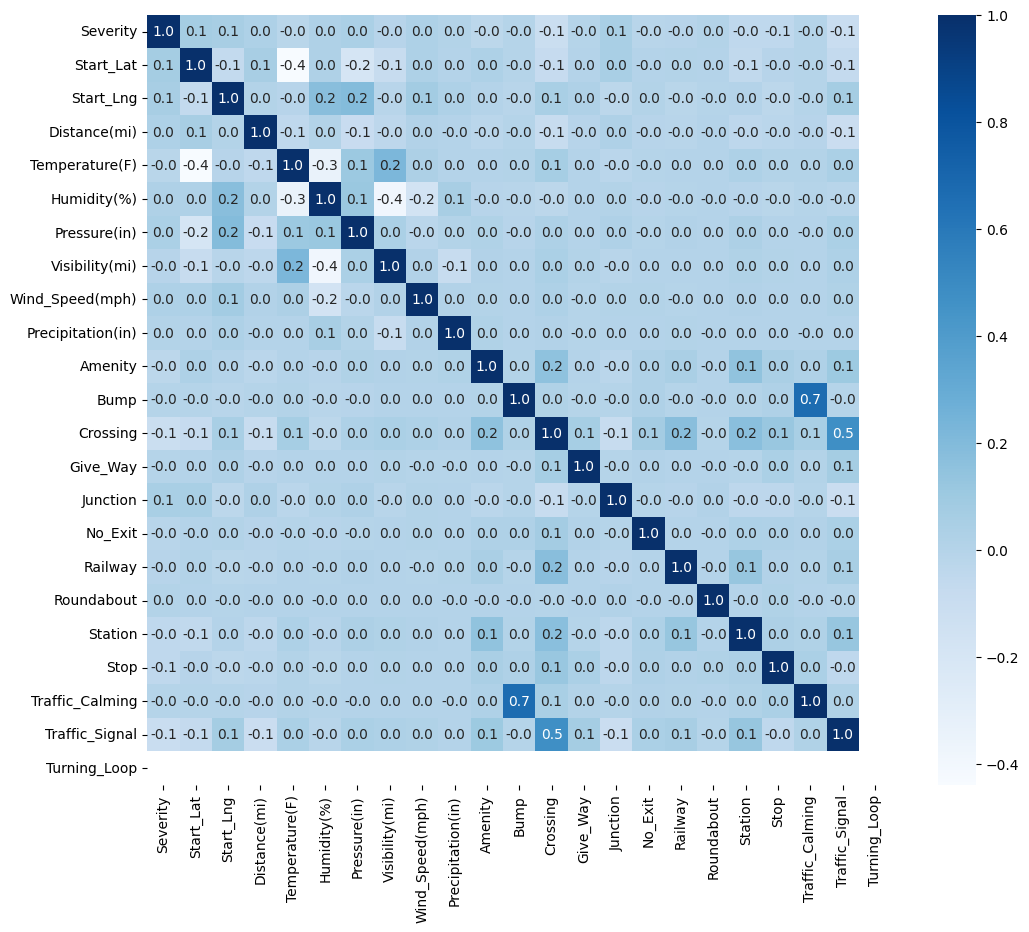

In [111]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt="0.1f", cmap="Blues",)